Converged after 3 iterations
Final centroids:
 [[7.92151163 3.05803431]
 [1.8442257  1.93286202]
 [5.01237767 9.21801572]]
Final SSE: 179.01428449591353


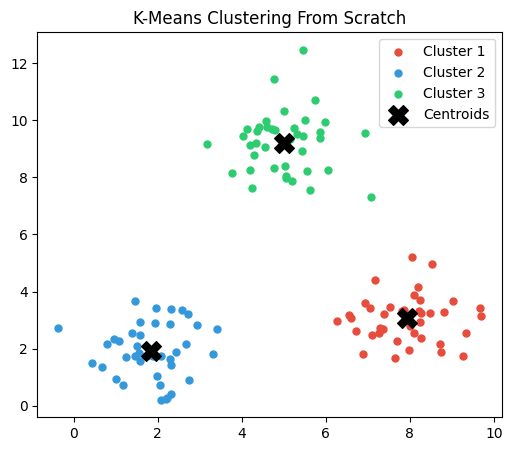

In [5]:
# Q. Implement the following machine learning algorithms from scratch using Python:
# a) K-Means Clustering:
# Implement the K-Means clustering algorithm without using the built-in KMeans function. The implementation must include centroid initialization, distance calculation, cluster assignment, centroid updating, and iteration until convergence.
import numpy as np
import matplotlib.pyplot as plt
 
np.random.seed(42)
 
# ---- Suitable dataset: 3 synthetic 2D blobs ----
def make_blobs(centers, n_per_cluster=40, std=0.8):
    pts = []
    for cx, cy in centers:
        pts.append(np.random.randn(n_per_cluster, 2) * std + [cx, cy])
    return np.vstack(pts)
 
X = make_blobs([(2,2), (8,3), (5,9)], n_per_cluster=40, std=0.9)
 
def kmeans_from_scratch(X, k, max_iters=100, tol=1e-4, seed=0):
    rng = np.random.default_rng(seed)
 
    # 1. CENTROID INITIALIZATION
    #    Pick k random data points as the starting centroids.
    idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[idx].copy()
 
    for iteration in range(max_iters):
        # 2. DISTANCE CALCULATION
        #    Euclidean distance from every point to every centroid.
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
 
        # 3. CLUSTER ASSIGNMENT
        #    Each point goes to whichever centroid is nearest.
        labels = np.argmin(distances, axis=1)
 
        # 4. CENTROID UPDATING
        #    Move each centroid to the mean of the points now assigned to it.
        new_centroids = np.array([
            X[labels == c].mean(axis=0) if np.any(labels == c) else centroids[c]
            for c in range(k)
        ])
 
        # 5. CONVERGENCE CHECK
        #    Stop once centroids move by less than a small tolerance.
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if shift < tol:
            print(f"Converged after {iteration+1} iterations")
            break
 
    return labels, centroids
 
labels, centroids = kmeans_from_scratch(X, k=3, seed=1)
 
# Verify: within-cluster SSE for the final solution
sse = sum(np.sum((X[labels==c] - centroids[c])**2) for c in range(3))
print("Final centroids:\n", centroids)
print("Final SSE:", sse)
 
# ---- Visualize ----
plt.figure(figsize=(6,5))
colors = ['#E74C3C', '#3498DB', '#2ECC71']
for c in range(3):
    plt.scatter(X[labels==c,0], X[labels==c,1], s=25, color=colors[c], label=f"Cluster {c+1}")
plt.scatter(centroids[:,0], centroids[:,1], s=200, c='black', marker='X', label="Centroids")
plt.title("K-Means Clustering From Scratch")
plt.legend(); plt.show()


Projected data: [ 4.46966918  3.48662485  3.06936143  5.22993727  5.30419602 12.35170446
  8.79082087 10.26538736 10.19112861 12.4259632 ]


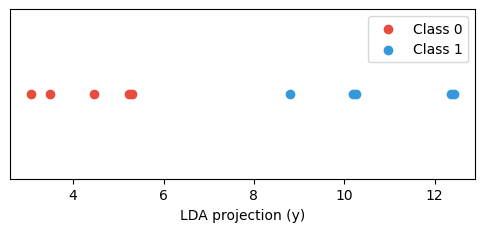

In [7]:
# b) Linear Discriminant Analysis (LDA):
# Implement LDA without using the built-in LDA function. Compute the within-class scatter matrix, between-class scatter matrix, eigenvalues/eigenvectors, and project the data onto the selected discriminant components.
# For both algorithms:
# Use a suitable dataset. 
# Do not use the corresponding machine-learning library implementation. 
# Display/visualize the final results. 
# Clearly explain the major steps in your Python implementation.
 
X1 = np.array([[4,2],[2,4],[2,3],[3,6],[4,4]])     # class 0
X2 = np.array([[9,10],[6,8],[9,5],[8,7],[10,8]])   # class 1
X = np.vstack([X1, X2])
y = np.array([0]*5 + [1]*5)
 
classes = np.unique(y)
n_features = X.shape[1]
 
# 1. Class-wise means and the overall mean
mean_overall = X.mean(axis=0)
mean_vectors = {c: X[y == c].mean(axis=0) for c in classes}
 
# 2. WITHIN-CLASS SCATTER MATRIX (Sw)
#    How tightly each class's points cluster around their OWN mean.
Sw = np.zeros((n_features, n_features))
for c in classes:
    Xc = X[y == c]; mc = mean_vectors[c]
    Sw += (Xc - mc).T @ (Xc - mc)
 
# 3. BETWEEN-CLASS SCATTER MATRIX (SB)
#    How far each class mean sits from the OVERALL mean.
SB = np.zeros((n_features, n_features))
for c in classes:
    Nc = X[y == c].shape[0]
    diff = (mean_vectors[c] - mean_overall).reshape(-1, 1)
    SB += Nc * (diff @ diff.T)
 
# 4. Solve the generalized eigenvalue problem for Sw^-1 SB
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Sw).dot(SB))
eigvals, eigvecs = eigvals.real, eigvecs.real
 
# 5. Select the top k discriminant vectors (k = min(features, classes-1))
k = min(n_features, len(classes) - 1)
order = np.argsort(eigvals)[::-1]
W = eigvecs[:, order[:k]]
 
# 6. Project the dataset onto the new subspace
X_lda = X.dot(W)
print("Projected data:", X_lda.ravel())
 
# 7. Visualize
plt.figure(figsize=(6,2.2))
plt.scatter(X_lda[y==0], np.zeros(5), c="#E74C3C", label="Class 0")
plt.scatter(X_lda[y==1], np.zeros(5), c="#3498DB", label="Class 1")
plt.yticks([]); plt.xlabel("LDA projection (y)"); plt.legend(); plt.show()
